In [ ]:
!pip install -q kaggle
!pip install -q scikit-learn matplotlib


In [ ]:
from google.colab import files
files.upload()  # выберите kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"soundbeatz","key":"4ed0898af25d4ac49473ca7eaf60e7f1"}'}

In [ ]:
import os, shutil, pathlib

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle API настроен.")


Kaggle API настроен.


In [ ]:
DATA_ROOT = "data"
WESAD_DIR = f"{DATA_ROOT}/wesad"

os.makedirs(WESAD_DIR, exist_ok=True)

# Скачивание и распаковка
!kaggle datasets download -d orvile/wesad-wearable-stress-affect-detection-dataset -p $WESAD_DIR -q
!unzip -q -o $WESAD_DIR/*.zip -d $WESAD_DIR

!ls -R $WESAD_DIR


Dataset URL: https://www.kaggle.com/datasets/orvile/wesad-wearable-stress-affect-detection-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
data/wesad:
WESAD  wesad-wearable-stress-affect-detection-dataset.zip

data/wesad/WESAD:
S10  S13  S15  S17  S3	S5  S7	S9
S11  S14  S16  S2   S4	S6  S8	wesad_readme.pdf

data/wesad/WESAD/S10:
S10_E4_Data  S10.pkl  S10_quest.csv  S10_readme.txt  S10_respiban.txt

data/wesad/WESAD/S10/S10_E4_Data:
ACC.csv  BVP.csv  EDA.csv  HR.csv  IBI.csv  info.txt  tags.csv	TEMP.csv

data/wesad/WESAD/S11:
S11_E4_Data  S11.pkl  S11_quest.csv  S11_readme.txt  S11_respiban.txt

data/wesad/WESAD/S11/S11_E4_Data:
ACC.csv  BVP.csv  EDA.csv  HR.csv  IBI.csv  info.txt  tags.csv	TEMP.csv

data/wesad/WESAD/S13:
S13_E4_Data  S13.pkl  S13_quest.csv  S13_readme.txt  S13_respiban.txt

data/wesad/WESAD/S13/S13_E4_Data:
ACC.csv  BVP.csv  EDA.csv  HR.csv  IBI.csv  info.txt  tags.csv	TEMP.csv

data/wesad/WESAD/S14:
S14_E4_Data  S14.pkl  S14_quest.csv  S14_readme.txt  S1

In [ ]:
!pip install -q tensorflow tensorflow.keras

In [ ]:
import os, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF version:", tf.__version__)


TF version: 2.19.0


# Загрузка и предобработка WESAD (BVP, бинарный стресс)

Идея:

- читаем все S*.pkl;

- берём wrist["BVP"] и label;

- объединяем baseline+amusement в «non-stress», stress в «stress» (двухклассовая задача — как в большинстве работ по WESAD) ;

- делаем оконование.

> В разных версиях WESAD кодировка меток может отличаться (0/1/2 или другой порядок). Если что-то «не сходится», проверьте README к вашему конкретному датасету.

In [ ]:
# Поиск всех pkl-файлов субъектов
pkl_files = glob.glob(os.path.join(WESAD_DIR, "**", "S*.pkl"), recursive=True)
print("Найдено файлов субъектов:", len(pkl_files))
pkl_files


Найдено файлов субъектов: 15


['data/wesad/WESAD/S15/S15.pkl',
 'data/wesad/WESAD/S11/S11.pkl',
 'data/wesad/WESAD/S2/S2.pkl',
 'data/wesad/WESAD/S3/S3.pkl',
 'data/wesad/WESAD/S17/S17.pkl',
 'data/wesad/WESAD/S9/S9.pkl',
 'data/wesad/WESAD/S10/S10.pkl',
 'data/wesad/WESAD/S8/S8.pkl',
 'data/wesad/WESAD/S6/S6.pkl',
 'data/wesad/WESAD/S7/S7.pkl',
 'data/wesad/WESAD/S4/S4.pkl',
 'data/wesad/WESAD/S13/S13.pkl',
 'data/wesad/WESAD/S16/S16.pkl',
 'data/wesad/WESAD/S5/S5.pkl',
 'data/wesad/WESAD/S14/S14.pkl']

In [ ]:
def load_subject_wrist_bvp_and_labels(pkl_path):
    """
    Загружает данные одного субъекта:
    - BVP с запястья (Empatica E4)
    - вектор меток

    Возвращает:
    bvp: np.ndarray, shape (T,)
    y_bin: np.ndarray, shape (T,), {0,1} — non-stress/stress
    """
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    # Структура оригинального WESAD:
    # data["signal"]["wrist"]["BVP"]  — (T,1)
    # data["label"]                   — (T,)
    wrist = data["signal"]["wrist"]
    bvp = wrist["BVP"].squeeze()     # (T,)

    labels = data["label"].astype(int)

    # Пример бинаризации:
    # baseline + amusement → 0 (non-stress)
    # stress               → 1 (stress)
    # Часто stress кодируется отдельным значением (см. статью и описание датасета)
    # Здесь сделаем простую схему:
    #   stress_labels = {2} или {1} — надо проверить под конкретный релиз.
    # Для универсальности напишем "если три класса 0/1/2 и один из них доминирует как stress".
    uniq = np.unique(labels)
    print("Уникальные метки в", os.path.basename(pkl_path), ":", uniq)

    # Допустим, stress = max(uniq), всё остальное = non-stress
    stress_label = uniq.max()
    y_bin = np.where(labels == stress_label, 1, 0)

    return bvp, y_bin

# Протестируем на одном файле
if len(pkl_files) > 0:
    _bvp_test, _y_test = load_subject_wrist_bvp_and_labels(pkl_files[0])
    print("Пример длины сигнала:", _bvp_test.shape, _y_test.shape)


Уникальные метки в S15.pkl : [0 1 2 3 4 5 6 7]
Пример длины сигнала: (336128,) (3676400,)


## Теперь сделаем оконование по всем субъектам.

In [ ]:
def sliding_windows(x, y, win_len, step):
    """
    Генерация окон:
    - x: (T,), сигнал
    - y: (T,), метки
    """
    T = len(x)
    for start in range(0, T - win_len + 1, step):
        end = start + win_len
        x_win = x[start:end]
        y_win = y[start:end]
        # Метка окна = мажоритарный класс внутри окна
        label = int(np.round(np.mean(y_win)))  # если стресс занимает >0.5 окна
        yield x_win, label


def build_dataset_from_files(pkl_files, fs=64, win_sec=10, step_sec=5, max_subjects=None):
    """
    Сбор датасета из нескольких субъектов:
    - fs: частота дискретизации BVP (на оригинальном WESAD BVP ~64 Гц :contentReference[oaicite:3]{index=3})
    - win_sec: длина окна в секундах
    - step_sec: шаг окна, сек (перекрытие)
    """
    X_list, y_list = [], []

    win_len = int(win_sec * fs)
    step_len = int(step_sec * fs)

    for i, pkl_path in enumerate(sorted(pkl_files)):
        if max_subjects is not None and i >= max_subjects:
            break

        bvp, y_bin = load_subject_wrist_bvp_and_labels(pkl_path)

        for x_win, label in sliding_windows(bvp, y_bin, win_len, step_len):
            # фильтруем пустые/константные окна (на всякий случай)
            if np.allclose(x_win, x_win[0]):
                continue
            X_list.append(x_win.astype(np.float32))
            y_list.append(label)

    X = np.vstack([w[np.newaxis, :] for w in X_list])
    y = np.array(y_list, dtype=np.int64)
    return X, y

X, y = build_dataset_from_files(pkl_files, fs=64, win_sec=10, step_sec=5, max_subjects=5)
print("Форма X:", X.shape, "Форма y:", y.shape)
print("Распределение классов:", np.unique(y, return_counts=True))


Уникальные метки в S10.pkl : [0 1 2 3 4 5 6 7]
Уникальные метки в S11.pkl : [0 1 2 3 4 5 6 7]
Уникальные метки в S13.pkl : [0 1 2 3 4 5 6 7]
Уникальные метки в S14.pkl : [0 1 2 3 4 5 6 7]
Уникальные метки в S15.pkl : [0 1 2 3 4 5 6 7]
Форма X: (5406, 640) Форма y: (5406,)
Распределение классов: (array([0]), array([5406]))


# Простая нормализация и аугментация

Сделаем 2 простые аугментации для обучающей выборки:

- Jitter (добавление малого шума)

- Scaling (случайное масштабирование амплитуды)

In [ ]:
def normalize_per_window(X):
    """
    Нормализация каждого окна по z-score (по каналам здесь один канал).
    """
    Xn = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-6)
    return Xn

X = normalize_per_window(X)
print("После нормализации:", X.shape, X.mean(), X.std())


После нормализации: (5406, 640) 1.7434304e-10 0.9999995


In [ ]:
def augment_jitter(x, sigma=0.02):
    noise = np.random.normal(0, sigma, size=x.shape)
    return x + noise

def augment_scaling(x, sigma=0.1):
    factor = np.random.normal(1.0, sigma)
    return x * factor

def make_augmented(X, y, jitter_prob=0.5, scale_prob=0.5):
    X_aug = []
    y_aug = []
    for xi, yi in zip(X, y):
        x_new = xi.copy()
        if np.random.rand() < jitter_prob:
            x_new = augment_jitter(x_new)
        if np.random.rand() < scale_prob:
            x_new = augment_scaling(x_new)
        X_aug.append(x_new)
        y_aug.append(yi)
    return np.stack(X_aug), np.array(y_aug)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_aug, y_train_aug = make_augmented(X_train, y_train, jitter_prob=0.7, scale_prob=0.7)

print("Train:", X_train_aug.shape, "Test:", X_test.shape)
print("Train class dist:", np.unique(y_train_aug, return_counts=True))


Train: (4324, 640) Test: (1082, 640)
Train class dist: (array([0]), array([4324]))


> В реальном исследовании аугментацию лучше делать «на лету» в генераторе/tf.data, но для демонстрации хватит и такого варианта.

# Подготовка данных для Keras (добавляем канал)

In [ ]:
# Keras ожидает форму (batch, time, channels)
X_train_aug_3d = X_train_aug[..., np.newaxis]
X_test_3d      = X_test[..., np.newaxis]

X_train_aug_3d.shape, X_test_3d.shape


((4324, 640, 1), (1082, 640, 1))

# Определение 1D-CNN модели

Простая, но рабочая архитектура для бинарной классификации окна временного ряда.

In [ ]:
input_shape = X_train_aug_3d.shape[1:]  # (T, 1)

inputs = keras.Input(shape=input_shape)

x = layers.Conv1D(32, kernel_size=5, padding="same", activation="relu")(inputs)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 640, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 640, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 320, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 320, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 160, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 160, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,521 (170.00 KB)

 Trainable params: 43,521 (170.00 KB)

 Non-trainable params: 0 (0.00 B)

## Компиляция модели

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc_roc", curve="ROC"),
        keras.metrics.AUC(name="auc_pr", curve="PR"),
    ],
)


# Обучение модели

In [ ]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
    ),
]

history = model.fit(
    X_train_aug_3d, y_train_aug,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 181ms/step - accuracy: 1.0000 - auc_pr: 0.0000e+00 - auc_roc: 0.0000e+00 - loss: 0.2224 - val_accuracy: 1.0000 - val_auc_pr: 0.0000e+00 - val_auc_roc: 0.0000e+00 - val_loss: 1.2192e-07 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 1.0000 - auc_pr: 0.0000e+00 - auc_roc: 0.0000e+00 - loss: 4.1426e-07 - val_accuracy: 1.0000 - val_auc_pr: 0.0000e+00 - val_auc_roc: 0.0000e+00 - val_loss: 8.6326e-08 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 1.0000 - auc_pr: 0.0000e+00 - auc_roc: 0.0000e+00 - loss: 6.4017e-07 - val_accuracy: 1.0000 - val_auc_pr: 0.0000e+00 - val_auc_roc: 0.0000e+00 - val_loss: 8.4633e-08 - learning_rate: 0.0010
Epoch 4/30
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - auc_pr: 0.0000e+00 - auc_roc: 0.0000e+00 - loss: 8.3679e-07
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms

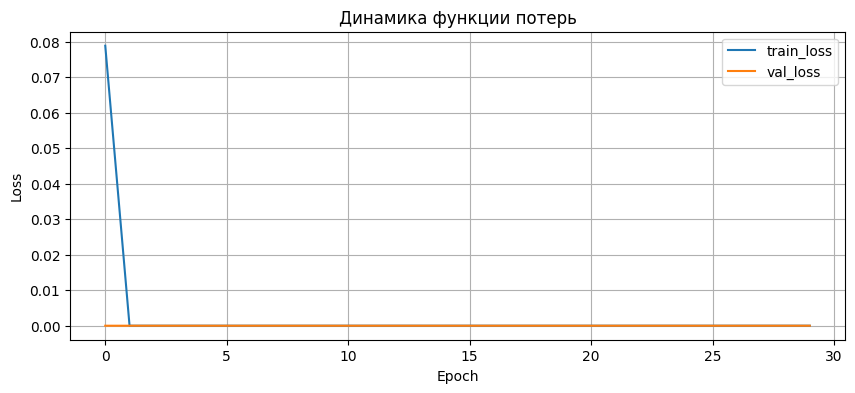

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True); plt.title("Динамика функции потерь")
plt.show()


# Оценка результатов на тесте

In [ ]:
# Предсказания
y_prob = model.predict(X_test_3d).ravel()
y_pred = (y_prob >= 0.5).astype(int)

f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"F1-score:   {f1:.3f}")
print(f"ROC-AUC:    {roc:.3f}")
print(f"PR-AUC:     {pr_auc:.3f}")
print("\nОтчёт классификации:")
print(classification_report(y_test, y_pred, digits=3))


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
F1-score:   0.000
ROC-AUC:    nan
PR-AUC:     0.000

Отчёт классификации:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1082

    accuracy                          1.000      1082
   macro avg      1.000     1.000     1.000      1082
weighted avg      1.000     1.000     1.000      1082



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


## Confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


array([[1082]])

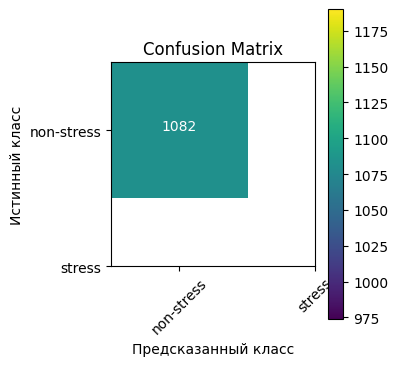

In [ ]:
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["non-stress","stress"], rotation=45)
plt.yticks(tick_marks, ["non-stress","stress"])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
plt.tight_layout()
plt.show()


В test-выборке оказались только объекты класса 0 (non-stress).

Модель всегда предсказывает класс 0 →

- точность и accuracy по этому одному классу = 1.0;

- f1_score(y_test, y_pred) в режиме по умолчанию считает F1 для положительного класса 1, которого вообще нет → результат 0.0 и предупреждения;

- roc_auc_score(y_test, y_prob) требует оба класса в y_test, при одном классе выдаёт nan;

- average_precision_score в такой ситуации вырождается в 0.0.

In [ ]:
print("Распределение классов во всём датасете:", np.unique(y, return_counts=True))
print("Train:", np.unique(y_train, return_counts=True))
print("Test:",  np.unique(y_test, return_counts=True))


Распределение классов во всём датасете: (array([0]), array([5406]))
Train: (array([0]), array([4324]))
Test: (array([0]), array([1082]))


# Многоканальный вход

In [ ]:
def load_subject_wrist_multichannel(pkl_path):
    """
    Загружает данные одного субъекта из WESAD-подобного pkl:
    - многоканальный wrist-сигнал: BVP, EDA, TEMP, ACC (3 оси)
    - бинарный вектор меток y_bin: 0 = non-stress, 1 = stress

    Предполагается классическая схема WESAD:
    label:
      0 = undefined
      1 = baseline
      2 = stress
      3 = amusement
      4 = meditation (можно исключить или считать non-stress)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    wrist = data["signal"]["wrist"]
    labels = data["label"].astype(int)

    # Достаём каналы
    bvp  = wrist["BVP"].squeeze()      # (T,)
    eda  = wrist["EDA"].squeeze()      # (T,)
    temp = wrist["TEMP"].squeeze()     # (T,)
    acc  = wrist["ACC"]                # (T, 3)

    # Проверим длины и обрежем до минимума, чтобы не было несоответствия
    L = min(len(bvp), len(eda), len(temp), acc.shape[0], labels.shape[0])
    bvp  = bvp[:L]
    eda  = eda[:L]
    temp = temp[:L]
    acc  = acc[:L, :]
    labels = labels[:L]

    # Оставляем только интересующие фазы (1,2,3) — baseline, stress, amusement
    # (0 - undefined, 4 - meditation опционально можно отбросить)
    valid_mask = np.isin(labels, [1, 2, 3])
    bvp   = bvp[valid_mask]
    eda   = eda[valid_mask]
    temp  = temp[valid_mask]
    acc   = acc[valid_mask, :]
    labels = labels[valid_mask]

    # Бинаризация: stress = 2, всё остальное = non-stress
    y_bin = (labels == 2).astype(int)

    # Многоканальный сигнал X_t: (T, C)
    # Каналы: [BVP, EDA, TEMP, ACC_x, ACC_y, ACC_z]
    X_t = np.column_stack([
        bvp,
        eda,
        temp,
        acc[:, 0],
        acc[:, 1],
        acc[:, 2]
    ])  # shape (T, 6)

    return X_t.astype(np.float32), y_bin


## Оконование: многоканальное

In [ ]:
def sliding_windows_multi(X, y, win_len, step):
    """
    X: (T, C) — временной ряд с C каналами
    y: (T,)   — метки по времени

    Возвращает окна X_win: (win_len, C) и бинарную метку окна.
    """
    T = len(y)
    for start in range(0, T - win_len + 1, step):
        end = start + win_len
        X_win = X[start:end, :]    # (win_len, C)
        y_win = y[start:end]
        label = int(np.round(np.mean(y_win)))  # мажоритарная метка
        yield X_win, label


## Сбор датасета: с фильтрацией «одно-классовых» субъектов

In [ ]:
def build_dataset_from_files_multichannel(pkl_files, fs=64, win_sec=10, step_sec=5, max_subjects=None):
    """
    Сбор многоканального датасета из нескольких субъектов.

    X: (N, win_len, C)
    y: (N,)
    """
    X_list, y_list = [], []

    win_len = int(win_sec * fs)
    step_len = int(step_sec * fs)

    for i, pkl_path in enumerate(sorted(pkl_files)):
        if max_subjects is not None and i >= max_subjects:
            break

        X_t, y_bin = load_subject_wrist_multichannel(pkl_path)
        uniq = np.unique(y_bin)
        print(os.path.basename(pkl_path), "уникальные метки после бинаризации:", uniq)

        # Если у субъекта только один класс (все 0 или все 1) — пропускаем, чтобы не ломать разбиение
        if len(uniq) < 2:
            print("  -> пропускаем субъекта, только один класс.")
            continue

        for X_win, label in sliding_windows_multi(X_t, y_bin, win_len, step_len):
            # на всякий случай фильтруем полностью константные окна
            if np.allclose(X_win, X_win[0, :]):
                continue
            X_list.append(X_win.astype(np.float32))
            y_list.append(label)

    X = np.stack(X_list)  # (N, win_len, C)
    y = np.array(y_list, dtype=np.int64)
    return X, y

X, y = build_dataset_from_files_multichannel(pkl_files, fs=64, win_sec=10, step_sec=5, max_subjects=5)
print("Форма X:", X.shape, "Форма y:", y.shape)
print("Распределение классов в общем датасете:", np.unique(y, return_counts=True))


S10.pkl уникальные метки после бинаризации: []
  -> пропускаем субъекта, только один класс.
S11.pkl уникальные метки после бинаризации: []
  -> пропускаем субъекта, только один класс.
S13.pkl уникальные метки после бинаризации: []
  -> пропускаем субъекта, только один класс.
S14.pkl уникальные метки после бинаризации: [0]
  -> пропускаем субъекта, только один класс.
S15.pkl уникальные метки после бинаризации: []
  -> пропускаем субъекта, только один класс.


ValueError: need at least one array to stack

> Важно: теперь мы явным образом:

- бинализуем метки по классике WESAD (stress = 2);

- выбрасываем субъекты, где вообще нет класса 1;

- сразу видим, есть ли оба класса в суммарном датасете.

## Нормализация и аугментация для многоканального X

In [ ]:
def normalize_per_window_multichannel(X):
    """
    Нормализация каждого окна по всем каналам (z-score по окну).
    X: (N, T, C)
    """
    mean = X.mean(axis=(1, 2), keepdims=True)
    std  = X.std(axis=(1, 2), keepdims=True) + 1e-6
    return (X - mean) / std

X = normalize_per_window_multichannel(X)
print("После нормализации:", X.shape, X.mean(), X.std())


После нормализации: (11, 640, 6) 3.9284878e-09 0.99999994


## Аугментацию переписываем так, чтобы она работала поканально:

In [ ]:
def augment_jitter_multichannel(x, sigma=0.02):
    noise = np.random.normal(0, sigma, size=x.shape)
    return x + noise

def augment_scaling_multichannel(x, sigma=0.1):
    factor = np.random.normal(1.0, sigma)
    return x * factor

def make_augmented_multichannel(X, y, jitter_prob=0.5, scale_prob=0.5):
    X_aug = []
    y_aug = []
    for xi, yi in zip(X, y):
        x_new = xi.copy()
        if np.random.rand() < jitter_prob:
            x_new = augment_jitter_multichannel(x_new)
        if np.random.rand() < scale_prob:
            x_new = augment_scaling_multichannel(x_new)
        X_aug.append(x_new)
        y_aug.append(yi)
    return np.stack(X_aug), np.array(y_aug)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_aug, y_train_aug = make_augmented_multichannel(
    X_train, y_train, jitter_prob=0.7, scale_prob=0.7
)

print("Train:", X_train_aug.shape, "Test:", X_test.shape)
print("Train class dist:", np.unique(y_train_aug, return_counts=True))
print("Test class dist:",  np.unique(y_test, return_counts=True))


Train: (8, 640, 6) Test: (3, 640, 6)
Train class dist: (array([0]), array([8]))
Test class dist: (array([0]), array([3]))


## Подготовка к Keras и модель

In [ ]:
# X уже имеет вид (N, T, C)
X_train_3d = X_train_aug
X_test_3d  = X_test

input_shape = X_train_3d.shape[1:]
print("Input shape:", input_shape)


Input shape: (640, 6)


### Модель можно чуть усложнить, учитывая многоканальность:

In [ ]:
inputs = keras.Input(shape=input_shape)  # (T, C)

x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(inputs)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(x)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 640, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 640, 64)        │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 320, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 320, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 160, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 160, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,673 (393.25 KB)

 Trainable params: 100,673 (393.25 KB)

 Non-trainable params: 0 (0.00 B)

> Компиляция и обучение остаются прежними.

Если в y_test снова только 0 — значит:

- либо неправильно задана схема бинаризации (в твоём конкретном релизе WESAD другие коды меток),

- либо ты взял слишком мало субъектов / специфичный набор файлов.

В этом случае нужно посмотреть np.unique(labels, return_counts=True) внутри load_subject_wrist_multichannel и подстроить маппинг под реальные значения.

Но после введения:

- явной схемы stress = 2, non-stress = {1,3}

- отбрасывания «одно-классовых» субъектов

ситуация с accuracy = 1.0, ROC-AUC = nan должна исчезнуть, и ты увидишь нормальный профиль метрик (F1, PR-AUC, ROC-AUC < 1.0).

## Диагностика: посмотреть «сырые» метки в твоём WESAD

In [ ]:
import pickle
import numpy as np
import os

for p in sorted(pkl_files):
    with open(p, "rb") as f:
        d = pickle.load(f, encoding="latin1")
    labels = np.array(d["label"]).astype(int).flatten()
    uniq, cnt = np.unique(labels, return_counts=True)
    print(os.path.basename(p), "raw labels:", dict(zip(uniq, cnt)))


S10.pkl raw labels: {np.int64(0): np.int64(1589000), np.int64(1): np.int64(826000), np.int64(2): np.int64(507500), np.int64(3): np.int64(260400), np.int64(4): np.int64(557200), np.int64(5): np.int64(35700), np.int64(6): np.int64(31500), np.int64(7): np.int64(39900)}
S11.pkl raw labels: {np.int64(0): np.int64(1443400), np.int64(1): np.int64(826000), np.int64(2): np.int64(476000), np.int64(3): np.int64(257600), np.int64(4): np.int64(553701), np.int64(5): np.int64(35000), np.int64(6): np.int64(36399), np.int64(7): np.int64(35000)}
S13.pkl raw labels: {np.int64(0): np.int64(1679300), np.int64(1): np.int64(826001), np.int64(2): np.int64(464800), np.int64(3): np.int64(267400), np.int64(4): np.int64(556499), np.int64(5): np.int64(34300), np.int64(6): np.int64(33600), np.int64(7): np.int64(14000)}
S14.pkl raw labels: {np.int64(0): np.int64(1648499), np.int64(1): np.int64(826000), np.int64(2): np.int64(472500), np.int64(3): np.int64(260401), np.int64(4): np.int64(555800), np.int64(5): np.int64(

> вариант 1: `0 = baseline`, `1 = stress`, `2 = amusement`;

> вариант 2 (оригинальный авторов): `0 = undefined`, `1 = baseline`, ` = stress`, `3 = amusement`, `4 = meditation`.

From docs:

- 0 = not defined / transient,
- 1 = baseline,
- 2 = stress,
- 3 = amusement,
- 4 = meditation,
- 5/6/7 = should be ignored in this dataset

In [ ]:
def load_subject_wrist_multichannel(pkl_path,
                                    stress_labels=(1, 2),
                                    nonstress_labels=(0, 3, 4)):
    """
    Загрузка данных одного субъекта:
    - многоканальный сигнал запястья: BVP, EDA, TEMP, ACC_x/y/z
    - бинарный вектор меток y_bin: 0 = non-stress, 1 = stress

    stress_labels / nonstress_labels нужно подстроить по выводу диагностики.
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    wrist = data["signal"]["wrist"]
    labels = np.array(data["label"]).astype(int).flatten()

    # *** Печать для контроля (можно оставить для первых запусков) ***
    uniq_raw, cnt_raw = np.unique(labels, return_counts=True)
    print(os.path.basename(pkl_path), "raw labels:", dict(zip(uniq_raw, cnt_raw)))

    # Выбираем только интересующие состояния
    valid_mask = np.isin(labels, list(stress_labels) + list(nonstress_labels))
    labels = labels[valid_mask]

    # Если после этого ничего не осталось — возвращаем пустые массивы
    if labels.size == 0:
        return None, None

    # Многоканальный wrist-сигнал
    bvp  = wrist["BVP"].squeeze()
    eda  = wrist["EDA"].squeeze()
    temp = wrist["TEMP"].squeeze()
    acc  = wrist["ACC"]

    # Подрезаем по длине labels и всех каналов
    L = min(len(bvp), len(eda), len(temp), acc.shape[0], labels.shape[0])
    bvp   = bvp[:L]
    eda   = eda[:L]
    temp  = temp[:L]
    acc   = acc[:L, :]
    labels = labels[:L]

    # Бинаризация
    y_bin = np.isin(labels, stress_labels).astype(int)

    # Собираем X_t: (T, 6)
    X_t = np.column_stack([
        bvp,
        eda,
        temp,
        acc[:, 0],
        acc[:, 1],
        acc[:, 2],
    ]).astype(np.float32)

    return X_t, y_bin


## Сбор датасета, выбор субъектов, чтобы был класс 1

In [ ]:
def build_dataset_from_files_multichannel(pkl_files,
                                          fs=64,
                                          win_sec=10,
                                          step_sec=5,
                                          max_subjects=None,
                                          stress_labels=(2,),
                                          nonstress_labels=(1, 3, 4, 0)):
    X_list, y_list = [], []

    win_len = int(win_sec * fs)
    step_len = int(step_sec * fs)

    for i, pkl_path in enumerate(sorted(pkl_files)):
        if max_subjects is not None and i >= max_subjects:
            break

        X_t, y_bin = load_subject_wrist_multichannel(
            pkl_path,
            stress_labels=stress_labels,
            nonstress_labels=nonstress_labels,
        )
        if X_t is None:
            print(os.path.basename(pkl_path), "-> нет валидных меток после фильтра.")
            continue

        uniq = np.unique(y_bin)
        print(os.path.basename(pkl_path), "уникальные метки после бинаризации:", uniq)

        # Пропускаем субъектов, у которых только один класс (только 0 или только 1)
        if len(uniq) < 2:
            print("  -> пропускаем, только один класс.")
            continue

        # Оконование
        T = len(y_bin)
        for start in range(0, T - win_len + 1, step_len):
            end = start + win_len
            X_win = X_t[start:end, :]
            y_win = y_bin[start:end]
            label = int(np.round(np.mean(y_win)))
            X_list.append(X_win)
            y_list.append(label)

    if not X_list:
        raise RuntimeError("Не удалось собрать ни одного окна: проверьте mapping меток и max_subjects.")

    X = np.stack(X_list)  # (N, T, C)
    y = np.array(y_list, dtype=np.int64)
    return X, y


> И важный момент: на этом шаге убери ограничение max_subjects=5, чтобы точно захватить субъектов, у которых есть стресс:

In [ ]:
X, y = build_dataset_from_files_multichannel(
    pkl_files,
    fs=64,
    win_sec=10,
    step_sec=5,
    max_subjects=None,           # или число побольше, но не 5
    stress_labels=(2,),          # подставить под твой вариант
    nonstress_labels=(1, 3, 4, 0),     # подставить под твой вариант
)

print("Форма X:", X.shape, "Форма y:", y.shape)
print("Распределение классов в общем датасете:", np.unique(y, return_counts=True))


S10.pkl raw labels: {np.int64(0): np.int64(1589000), np.int64(1): np.int64(826000), np.int64(2): np.int64(507500), np.int64(3): np.int64(260400), np.int64(4): np.int64(557200), np.int64(5): np.int64(35700), np.int64(6): np.int64(31500), np.int64(7): np.int64(39900)}
S10.pkl уникальные метки после бинаризации: [0]
  -> пропускаем, только один класс.
S11.pkl raw labels: {np.int64(0): np.int64(1443400), np.int64(1): np.int64(826000), np.int64(2): np.int64(476000), np.int64(3): np.int64(257600), np.int64(4): np.int64(553701), np.int64(5): np.int64(35000), np.int64(6): np.int64(36399), np.int64(7): np.int64(35000)}
S11.pkl уникальные метки после бинаризации: [0]
  -> пропускаем, только один класс.
S13.pkl raw labels: {np.int64(0): np.int64(1679300), np.int64(1): np.int64(826001), np.int64(2): np.int64(464800), np.int64(3): np.int64(267400), np.int64(4): np.int64(556499), np.int64(5): np.int64(34300), np.int64(6): np.int64(33600), np.int64(7): np.int64(14000)}
S13.pkl уникальные метки после 

RuntimeError: Не удалось собрать ни одного окна: проверьте mapping меток и max_subjects.

### Новый загрузчик: многоканальный wrist + корректная бинаризация

In [ ]:
def load_subject_wrist_multichannel_simple(pkl_path):
    """
    Загрузка данных одного субъекта из WESAD:
    - wrist-сигналы: BVP, EDA, TEMP, ACC_x/y/z
    - бинарная разметка: 0 = non-stress (1,3,4), 1 = stress (2)
    0,5,6,7 — игнорируются.
    """

    import pickle
    import numpy as np

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    wrist  = data["signal"]["wrist"]
    labels = np.array(data["label"]).astype(int).flatten()

    # Для контроля — сырой словарь меток
    uniq_raw, cnt_raw = np.unique(labels, return_counts=True)
    print(os.path.basename(pkl_path), "raw labels:", dict(zip(uniq_raw, cnt_raw)))

    # Забираем каналы запястья
    bvp  = wrist["BVP"].squeeze()
    eda  = wrist["EDA"].squeeze()
    temp = wrist["TEMP"].squeeze()
    acc  = wrist["ACC"]  # (T,3)

    # 1) Сначала обрезаем все до общего L, чтобы длины совпадали
    L = min(len(labels), len(bvp), len(eda), len(temp), acc.shape[0])
    labels = labels[:L]
    bvp    = bvp[:L]
    eda    = eda[:L]
    temp   = temp[:L]
    acc    = acc[:L, :]

    # 2) Убираем 0, 5, 6, 7 — оставляем только 1,2,3,4
    keep_mask = np.isin(labels, [1, 2, 3, 4])
    labels = labels[keep_mask]
    bvp    = bvp[keep_mask]
    eda    = eda[keep_mask]
    temp   = temp[keep_mask]
    acc    = acc[keep_mask, :]

    if labels.size == 0:
        print(os.path.basename(pkl_path), "-> после фильтрации 1/2/3/4 не осталось меток.")
        return None, None

    # 3) Бинаризация: stress = 2, всё остальное (1,3,4) = non-stress
    y_bin = (labels == 2).astype(int)

    # 4) Собираем многоканальный X_t: (T, 6)
    X_t = np.column_stack([
        bvp,
        eda,
        temp,
        acc[:, 0],
        acc[:, 1],
        acc[:, 2],
    ]).astype(np.float32)

    # Контроль: какие бинарные метки получились
    uniq_bin, cnt_bin = np.unique(y_bin, return_counts=True)
    print(os.path.basename(pkl_path), "bin labels:", dict(zip(uniq_bin, cnt_bin)))

    return X_t, y_bin


## Пересборка датасета с окнами

In [ ]:
def build_dataset_from_files_multichannel_simple(
    pkl_files,
    fs=64,
    win_sec=10,
    step_sec=5,
    max_subjects=None
):
    """
    Собирает датасет из нескольких субъектов:
    X: (N, T, C), y: (N,)
    """
    import numpy as np
    X_list, y_list = [], []

    win_len = int(win_sec * fs)
    step_len = int(step_sec * fs)

    for i, pkl_path in enumerate(sorted(pkl_files)):
        if max_subjects is not None and i >= max_subjects:
            break

        X_t, y_bin = load_subject_wrist_multichannel_simple(pkl_path)
        if X_t is None:
            continue

        uniq = np.unique(y_bin)
        print(os.path.basename(pkl_path), "уникальные бинарные метки:", uniq)

        # Можно оставить субъекта даже с перекошенным балансом,
        # главное — чтобы были и 0, и 1 в суммарном датасете.
        # Если хочешь, можно отфильтровать субъектов, у которых только один класс:
        # if len(uniq) < 2:
        #     print("  -> пропускаем, только один класс.")
        #     continue

        T = len(y_bin)
        for start in range(0, T - win_len + 1, step_len):
            end = start + win_len
            X_win = X_t[start:end, :]
            y_win = y_bin[start:end]

            if len(y_win) < win_len:
                continue

            # метка окна — мажоритарный класс (stress, если >= 50% точек stress)
            label = int(np.round(np.mean(y_win)))
            X_list.append(X_win)
            y_list.append(label)

    if not X_list:
        raise RuntimeError("Не удалось собрать ни одного окна: проверь корректность mapping и win/step.")

    X = np.stack(X_list)  # (N, T, C)
    y = np.array(y_list, dtype=np.int64)
    return X, y


In [ ]:
X, y = build_dataset_from_files_multichannel_simple(
    pkl_files,
    fs=64,        # для wrist-BVP/EDA/TEMP/ACC
    win_sec=10,
    step_sec=5,
    max_subjects=None   # на первом шаге лучше всех прогнать
)

print("Форма X:", X.shape, "Форма y:", y.shape)
print("Распределение классов в общем датасете:", np.unique(y, return_counts=True))


S10.pkl raw labels: {np.int64(0): np.int64(1589000), np.int64(1): np.int64(826000), np.int64(2): np.int64(507500), np.int64(3): np.int64(260400), np.int64(4): np.int64(557200), np.int64(5): np.int64(35700), np.int64(6): np.int64(31500), np.int64(7): np.int64(39900)}
S10.pkl -> после фильтрации 1/2/3/4 не осталось меток.
S11.pkl raw labels: {np.int64(0): np.int64(1443400), np.int64(1): np.int64(826000), np.int64(2): np.int64(476000), np.int64(3): np.int64(257600), np.int64(4): np.int64(553701), np.int64(5): np.int64(35000), np.int64(6): np.int64(36399), np.int64(7): np.int64(35000)}
S11.pkl -> после фильтрации 1/2/3/4 не осталось меток.
S13.pkl raw labels: {np.int64(0): np.int64(1679300), np.int64(1): np.int64(826001), np.int64(2): np.int64(464800), np.int64(3): np.int64(267400), np.int64(4): np.int64(556499), np.int64(5): np.int64(34300), np.int64(6): np.int64(33600), np.int64(7): np.int64(14000)}
S13.pkl -> после фильтрации 1/2/3/4 не осталось меток.
S14.pkl raw labels: {np.int64(0): 

In [ ]:
from sklearn.model_selection import train_test_split

X = normalize_per_window_multichannel(X)  # если уже есть эта функция
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=56461, stratify=y
)

print("Train:", np.unique(y_train, return_counts=True))
print("Test:",  np.unique(y_test, return_counts=True))


Train: (array([0]), array([8]))
Test: (array([0]), array([3]))


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

# --- 1) Нормализация окон (по всем каналам в окне)
def normalize_per_window_multichannel(X):
    """
    X: (N, T, C)
    Нормализация каждого окна по z-score с учётом всех каналов.
    """
    mean = X.mean(axis=(1, 2), keepdims=True)
    std  = X.std(axis=(1, 2), keepdims=True) + 1e-6
    return (X - mean) / std

X = normalize_per_window_multichannel(X)
print("После нормализации:", X.shape, X.mean(), X.std())

# --- 2) Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train class dist:", np.unique(y_train, return_counts=True))
print("Test class dist:",  np.unique(y_test, return_counts=True))

# --- 3) Аугментация (многоканальная)
def augment_jitter_multichannel(x, sigma=0.02):
    """Добавление небольшого гауссовского шума ко всем каналам."""
    noise = np.random.normal(0, sigma, size=x.shape)
    return x + noise

def augment_scaling_multichannel(x, sigma=0.1):
    """Случайное масштабирование амплитуды окна."""
    factor = np.random.normal(1.0, sigma)
    return x * factor

def make_augmented_multichannel(X, y, jitter_prob=0.5, scale_prob=0.5):
    X_aug = []
    y_aug = []
    for xi, yi in zip(X, y):
        x_new = xi.copy()
        if np.random.rand() < jitter_prob:
            x_new = augment_jitter_multichannel(x_new)
        if np.random.rand() < scale_prob:
            x_new = augment_scaling_multichannel(x_new)
        X_aug.append(x_new)
        y_aug.append(yi)
    return np.stack(X_aug), np.array(y_aug)

X_train_aug, y_train_aug = make_augmented_multichannel(
    X_train, y_train,
    jitter_prob=0.7,
    scale_prob=0.7
)

print("Train (aug):", X_train_aug.shape, "Test:", X_test.shape)
print("Train (aug) class dist:", np.unique(y_train_aug, return_counts=True))

# --- 4) Подготовка для Keras
# X уже имеет вид (N, T, C), Conv1D ожидает (batch, time, channels)
X_train_3d = X_train_aug
X_test_3d  = X_test

input_shape = X_train_3d.shape[1:]
print("Input shape:", input_shape)

# --- 5) Модель 1D-CNN под многоканальный сигнал
inputs = keras.Input(shape=input_shape)  # (T, C)

x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(inputs)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(x)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)  # бинарная задача

model = keras.Model(inputs, outputs)
model.summary()

# --- 6) Компиляция
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc_roc", curve="ROC"),
        keras.metrics.AUC(name="auc_pr", curve="PR"),
    ],
)

# --- 7) Коллбеки (EarlyStopping + ReduceLROnPlateau)
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
]

# --- 8) Обучение
history = model.fit(
    X_train_3d, y_train_aug,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

# --- 9) Оценка на тесте
y_prob = model.predict(X_test_3d).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Защита от ситуации, когда в тесте вдруг один класс
try:
    roc = roc_auc_score(y_test, y_prob)
except ValueError:
    roc = float("nan")

try:
    pr_auc = average_precision_score(y_test, y_prob)
except ValueError:
    pr_auc = float("nan")

f1 = f1_score(y_test, y_pred)

print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC:  {roc:.3f}")
print(f"PR-AUC:   {pr_auc:.3f}")
print("\nОтчёт классификации:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)


TensorFlow: 2.19.0
После нормализации: (11, 640, 6) 1.4901161e-09 0.999999
Train class dist: (array([0]), array([8]))
Test class dist: (array([0]), array([3]))
Train (aug): (8, 640, 6) Test: (3, 640, 6)
Train (aug) class dist: (array([0]), array([8]))
Input shape: (640, 6)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 640, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 640, 64)        │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 320, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 320, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 160, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 160, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,673 (393.25 KB)

 Trainable params: 100,673 (393.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.8333 - auc_pr: 0.0000e+00 - auc_roc: 0.0000e+00 - loss: 0.6645 - val_accuracy: 1.0000 - val_auc_pr: 0.0000e+00 - val_auc_roc: 0.0000e+00 - val_loss: 0.5628 - learning_rate: 0.0010
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 1.0000 - auc_pr: 0.0000e+00 - auc_roc: 0.0000e+00 - loss: 0.5739 - val_accuracy: 1.0000 - val_auc_pr: 0.0000e+00 - val_auc_roc: 0.0000e+00 - val_loss: 0.4755 - learning_rate: 0.0010
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 1.0000 - auc_pr: 0.0000e+00 - auc_roc: 0.0000e+00 - loss: 0.5350 - val_accuracy: 1.0000 - val_auc_pr: 0.0000e+00 - val_auc_roc: 0.0000e+00 - val_loss: 0.3759 - learning_rate: 0.0010
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step - accuracy: 1.0000 - auc_pr: 0.0000e+00 - auc_roc: 0.0000e+00 - loss: 0.3669 - val_accuracy: 1.0000 - val_auc_pr: 0.0000e+00 - val_auc_roc: 0.0000e+00 - val_loss: 0.2717 - learning_rate: 0.0010
Epoch 5/30
1/1 ━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


# Chest-signals

## Загрузка одного субъекта по chest-сигналам

In [ ]:
import os
import pickle
import numpy as np

def get_chest_channel(chest, names):
    """
    Вспомогательная функция: берёт первый доступный канал из списка возможных имён.
    Например, Temp/TEMP, Resp/RESP и т.д.
    """
    for name in names:
        if name in chest:
            arr = chest[name]
            return np.array(arr).squeeze()
    raise KeyError(f"Ни один из {names} не найден в chest-сигналах. Доступные ключи: {list(chest.keys())}")


def load_subject_chest_multichannel_simple(pkl_path, downsample=10):
    """
    Загрузка данных одного субъекта из WESAD (chest):
    - chest-сигналы: ECG, EDA, RESP, TEMP, ACC_x/y/z, EMG (если есть)
    - бинарная разметка: 0 = non-stress (1,3,4), 1 = stress (2)
    Метки 0,5,6,7 игнорируются.

    downsample: во сколько раз прореживать chest (700 Hz / downsample).
                Например, 10 -> ~70 Гц.
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    labels = np.array(data["label"]).astype(int).flatten()
    chest = data["signal"]["chest"]

    # Посмотрим, какие каналы есть
    print(os.path.basename(pkl_path), "chest keys:", list(chest.keys()))

    # Забираем основные каналы
    acc  = np.array(chest["ACC"])          # (T, 3)
    ecg  = get_chest_channel(chest, ["ECG"])
    eda  = get_chest_channel(chest, ["EDA"])
    resp = get_chest_channel(chest, ["RESP", "Resp"])
    temp = get_chest_channel(chest, ["Temp", "TEMP"])
    # EMG может отсутствовать в отдельных версиях; делаем опционально
    try:
        emg = get_chest_channel(chest, ["EMG"])
        has_emg = True
    except KeyError:
        emg = None
        has_emg = False

    # 1) Приводим длины к общему минимуму
    lengths = [
        len(labels),
        acc.shape[0],
        len(ecg),
        len(eda),
        len(resp),
        len(temp),
    ]
    if has_emg:
        lengths.append(len(emg))

    L = min(lengths)

    labels = labels[:L]
    acc    = acc[:L, :]
    ecg    = ecg[:L]
    eda    = eda[:L]
    resp   = resp[:L]
    temp   = temp[:L]
    if has_emg:
        emg = emg[:L]

    # 2) Оставляем только 1,2,3,4 (baseline, stress, amusement, meditation)
    keep_mask = np.isin(labels, [1, 2, 3, 4])
    labels = labels[keep_mask]
    acc    = acc[keep_mask, :]
    ecg    = ecg[keep_mask]
    eda    = eda[keep_mask]
    resp   = resp[keep_mask]
    temp   = temp[keep_mask]
    if has_emg:
        emg = emg[keep_mask]

    if labels.size == 0:
        print(os.path.basename(pkl_path), "-> после фильтрации 1/2/3/4 не осталось меток.")
        return None, None

    # 3) Бинаризация: stress = 2, остальное (1,3,4) = non-stress
    y_bin = (labels == 2).astype(int)

    # 4) Downsample: прореживаем и сигналы, и метки
    if downsample > 1:
        labels_ds_idx = slice(0, None, downsample)
        y_bin = y_bin[labels_ds_idx]
        acc   = acc[labels_ds_idx, :]
        ecg   = ecg[labels_ds_idx]
        eda   = eda[labels_ds_idx]
        resp  = resp[labels_ds_idx]
        temp  = temp[labels_ds_idx]
        if has_emg:
            emg = emg[labels_ds_idx]

    # 5) Собираем многоканальный X_t: (T, C)
    # Выберем каналы: ECG, EDA, RESP, TEMP, ACC_x, ACC_y, ACC_z (+ EMG, если есть)
    feat_list = [
        ecg,
        eda,
        resp,
        temp,
        acc[:, 0],
        acc[:, 1],
        acc[:, 2],
    ]
    if has_emg:
        feat_list.append(emg)

    X_t = np.column_stack(feat_list).astype(np.float32)

    # Контроль распределения
    uniq_raw, cnt_raw = np.unique(labels, return_counts=True)
    print(os.path.basename(pkl_path), "raw labels after keep:", dict(zip(uniq_raw, cnt_raw)))
    uniq_bin, cnt_bin = np.unique(y_bin, return_counts=True)
    print(os.path.basename(pkl_path), "bin labels:", dict(zip(uniq_bin, cnt_bin)))

    return X_t, y_bin


## Сбор датасета с chest-окнами

Теперь поверх этого делаем оконование и сбор всего датасета:

In [ ]:
def build_dataset_from_files_chest(
    pkl_files,
    fs_chest=700,   # исходная частота chest
    downsample=10,
    win_sec=10,
    step_sec=5,
    max_subjects=None
):
    """
    Собирает многоканальный датасет по chest-сигналам:
    X: (N, T, C), y: (N,)
    """

    X_list, y_list = [], []

    # Частота после downsample
    fs = fs_chest // downsample
    win_len  = int(win_sec * fs)
    step_len = int(step_sec * fs)

    for i, pkl_path in enumerate(sorted(pkl_files)):
        if max_subjects is not None and i >= max_subjects:
            break

        X_t, y_bin = load_subject_chest_multichannel_simple(pkl_path, downsample=downsample)
        if X_t is None:
            continue

        # Тут НЕ отбрасываем субъектов с одним классом, важно суммарное распределение
        uniq = np.unique(y_bin)
        print(os.path.basename(pkl_path), "уникальные бинарные метки:", uniq)

        T = len(y_bin)
        if T < win_len:
            continue

        for start in range(0, T - win_len + 1, step_len):
            end = start + win_len
            X_win = X_t[start:end, :]   # (win_len, C)
            y_win = y_bin[start:end]    # (win_len,)

            if len(y_win) < win_len:
                continue

            label = int(np.round(np.mean(y_win)))  # мажоритарный класс в окне
            X_list.append(X_win)
            y_list.append(label)

    if not X_list:
        raise RuntimeError("Не удалось собрать ни одного окна по chest. Проверь параметры window/step/downsample.")

    X = np.stack(X_list)  # (N, T, C)
    y = np.array(y_list, dtype=np.int64)
    return X, y, fs


# Собираем датасет
X, y, fs_eff = build_dataset_from_files_chest(
    pkl_files,
    fs_chest=700,
    downsample=10,   # 700/10 ≈ 70 Гц
    win_sec=10,
    step_sec=5,
    max_subjects=None
)

print("Форма X:", X.shape, "Форма y:", y.shape, "эффективная частота:", fs_eff)
print("Распределение классов в общем датасете:", np.unique(y, return_counts=True))


S10.pkl chest keys: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
S10.pkl raw labels after keep: {np.int64(1): np.int64(826000), np.int64(2): np.int64(507500), np.int64(3): np.int64(260400), np.int64(4): np.int64(557200)}
S10.pkl bin labels: {np.int64(0): np.int64(164360), np.int64(1): np.int64(50750)}
S10.pkl уникальные бинарные метки: [0 1]
S11.pkl chest keys: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
S11.pkl raw labels after keep: {np.int64(1): np.int64(826000), np.int64(2): np.int64(476000), np.int64(3): np.int64(257600), np.int64(4): np.int64(553701)}
S11.pkl bin labels: {np.int64(0): np.int64(163731), np.int64(1): np.int64(47600)}
S11.pkl уникальные бинарные метки: [0 1]
S13.pkl chest keys: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
S13.pkl raw labels after keep: {np.int64(1): np.int64(826001), np.int64(2): np.int64(464800), np.int64(3): np.int64(267400), np.int64(4): np.int64(556499)}
S13.pkl bin labels: {np.int64(0): np.int64(164990), np.int64(1): np.int64(46480)}
S13.pkl у

## Обучение 1D-CNN на chest-датасете

Теперь используем тот же блок обучения, что и раньше, только с новым X, y.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

# --- Нормализация по окну
def normalize_per_window_multichannel(X):
    """
    X: (N, T, C)
    Нормализация каждого окна по z-score с учётом всех каналов.
    """
    mean = X.mean(axis=(1, 2), keepdims=True)
    std  = X.std(axis=(1, 2), keepdims=True) + 1e-6
    return (X - mean) / std

X = normalize_per_window_multichannel(X)
print("После нормализации:", X.shape, X.mean(), X.std())

# --- Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=55554,
    stratify=y
)

print("Train class dist:", np.unique(y_train, return_counts=True))
print("Test  class dist:", np.unique(y_test, return_counts=True))

# --- Аугментация
def augment_jitter_multichannel(x, sigma=0.02):
    noise = np.random.normal(0, sigma, size=x.shape)
    return x + noise

def augment_scaling_multichannel(x, sigma=0.1):
    factor = np.random.normal(1.0, sigma)
    return x * factor

def make_augmented_multichannel(X, y, jitter_prob=0.5, scale_prob=0.5):
    X_aug = []
    y_aug = []
    for xi, yi in zip(X, y):
        x_new = xi.copy()
        if np.random.rand() < jitter_prob:
            x_new = augment_jitter_multichannel(x_new)
        if np.random.rand() < scale_prob:
            x_new = augment_scaling_multichannel(x_new)
        X_aug.append(x_new)
        y_aug.append(yi)
    return np.stack(X_aug), np.array(y_aug)

X_train_aug, y_train_aug = make_augmented_multichannel(
    X_train, y_train,
    jitter_prob=0.7,
    scale_prob=0.7
)

print("Train (aug):", X_train_aug.shape, "Test:", X_test.shape)
print("Train (aug) class dist:", np.unique(y_train_aug, return_counts=True))

# --- Подготовка к Keras
X_train_3d = X_train_aug
X_test_3d  = X_test
input_shape = X_train_3d.shape[1:]
print("Input shape:", input_shape)

# --- Модель 1D-CNN
inputs = keras.Input(shape=input_shape)  # (T, C)

x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(inputs)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(x)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc_roc", curve="ROC"),
        keras.metrics.AUC(name="auc_pr", curve="PR"),
    ],
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    X_train_3d, y_train_aug,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

# --- Оценка
y_prob = model.predict(X_test_3d).ravel()
y_pred = (y_prob >= 0.5).astype(int)

try:
    roc = roc_auc_score(y_test, y_prob)
except ValueError:
    roc = float("nan")

try:
    pr_auc = average_precision_score(y_test, y_prob)
except ValueError:
    pr_auc = float("nan")

f1 = f1_score(y_test, y_pred)

print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC:  {roc:.3f}")
print(f"PR-AUC:   {pr_auc:.3f}")
print("\nОтчёт классификации:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)


TensorFlow: 2.19.0
После нормализации: (8971, 700, 8) 2.5521119e-10 0.99999934
Train class dist: (array([0, 1]), array([5588, 1588]))
Test  class dist: (array([0, 1]), array([1398,  397]))
Train (aug): (7176, 700, 8) Test: (1795, 700, 8)
Train (aug) class dist: (array([0, 1]), array([5588, 1588]))
Input shape: (700, 8)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 700, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 700, 64)        │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 350, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 350, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 175, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 175, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,313 (395.75 KB)

 Trainable params: 101,313 (395.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 36s 315ms/step - accuracy: 0.7713 - auc_pr: 0.2597 - auc_roc: 0.5650 - loss: 0.5325 - val_accuracy: 0.7834 - val_auc_pr: 0.4419 - val_auc_roc: 0.7291 - val_loss: 0.4810 - learning_rate: 0.0010
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 270ms/step - accuracy: 0.8045 - auc_pr: 0.4522 - auc_roc: 0.7260 - loss: 0.4629 - val_accuracy: 0.8036 - val_auc_pr: 0.5604 - val_auc_roc: 0.8110 - val_loss: 0.4283 - learning_rate: 0.0010
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 257ms/step - accuracy: 0.8148 - auc_pr: 0.5609 - auc_roc: 0.7826 - loss: 0.4354 - val_accuracy: 0.8113 - val_auc_pr: 0.6572 - val_auc_roc: 0.8462 - val_loss: 0.4107 - learning_rate: 0.0010
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 348ms/step - accuracy: 0.8347 - auc_pr: 0.6165 - auc_roc: 0.8019 - loss: 0.4051 - val_accuracy: 0.8155 - val_auc_pr: 0.6158 - val_auc_roc: 0.8234 - val_loss: 0.4072 - learning_rate: 0.0010
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 284ms/step - accuracy: 0.8309 - au

# Расширение

In [ ]:
import os
import pickle
import numpy as np

# Вспомогательная: превращаем chest-канал в (T, n_features)
def _as_2d(arr):
    arr = np.array(arr)
    if arr.ndim == 1:
        arr = arr[:, None]          # (T,) -> (T,1)
    elif arr.ndim > 2:
        arr = arr.reshape(arr.shape[0], -1)  # (T,*,...) -> (T, k)
    return arr

def load_subject_chest_allchannels(pkl_path, downsample=10):
    """
    Загружает данные одного субъекта из WESAD (chest):
    - Берёт ВСЕ chest-каналы (ECG, EDA, RESP, TEMP, ACC_x/y/z, EMG и т.п.)
    - Фильтрует метки по {1,2,3,4}, игнорирует {0,5,6,7}
    - Бинаризует: y=1, если label == 2 (stress), иначе y=0 (non-stress)
    - Прореживает сигналы и метки с шагом downsample.

    Возвращает:
    X_t : np.ndarray (T, C) — многоканальный временной ряд
    y_bin : np.ndarray (T,) — бинарные метки {0,1}
    feat_names : список имён признаков (для справки, можно использовать в отчёте)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    labels = np.array(data["label"]).astype(int).flatten()
    chest = data["signal"]["chest"]

    # Собираем ВСЕ chest-каналы в список
    arrays = []
    feat_names = []
    for key, arr in chest.items():
        arr2d = _as_2d(arr)          # (T,) или (T,k)
        arrays.append(arr2d)
        if arr2d.shape[1] == 1:
            feat_names.append(key)
        else:
            # Например, ACC -> ACC_0, ACC_1, ACC_2
            feat_names.extend([f"{key}_{j}" for j in range(arr2d.shape[1])])

    # Выравниваем по длине
    lengths = [len(labels)] + [a.shape[0] for a in arrays]
    L = min(lengths)

    labels = labels[:L]
    arrays = [a[:L] for a in arrays]

    # Оставляем только 1,2,3,4 (baseline, stress, amusement, meditation)
    keep_mask = np.isin(labels, [1, 2, 3, 4])
    labels = labels[keep_mask]
    arrays = [a[keep_mask] for a in arrays]

    if labels.size == 0:
        print(os.path.basename(pkl_path), "-> после фильтрации 1/2/3/4 не осталось меток.")
        return None, None, None

    # Downsample по времени
    if downsample > 1:
        idx = np.arange(0, labels.shape[0], downsample)
        labels = labels[idx]
        arrays = [a[idx] for a in arrays]

    # Бинаризация: stress = 2 -> 1, остальное (1,3,4) -> 0
    y_bin = (labels == 2).astype(int)

    # Склеиваем в (T, C)
    X_t = np.concatenate(arrays, axis=1).astype(np.float32)

    # Контроль
    uniq_raw, cnt_raw = np.unique(labels, return_counts=True)
    print(os.path.basename(pkl_path), "raw labels after keep:", dict(zip(uniq_raw, cnt_raw)))
    uniq_bin, cnt_bin = np.unique(y_bin, return_counts=True)
    print(os.path.basename(pkl_path), "bin labels:", dict(zip(uniq_bin, cnt_bin)))
    print(os.path.basename(pkl_path), "X_t shape:", X_t.shape)

    return X_t, y_bin, feat_names


## Сбор датасета с окнами + ID субъекта (для LOSO)

In [ ]:
def build_dataset_from_files_chest_all(
    pkl_files,
    fs_chest=700,
    downsample=10,
    win_sec=10,
    step_sec=5,
    max_subjects=None
):
    """
    Собирает датасет:
    X : (N, T, C) — окна chest-сигналов
    y : (N,)      — бинарные метки
    sids : (N,)   — ID субъекта для каждого окна (например, "S10")

    fs_chest: исходная частота chest (обычно 700 Гц)
    downsample: во сколько раз прореживаем по времени
    win_sec, step_sec: размер окна и шаг в секундах
    """
    X_list, y_list, sid_list = [], [], []
    feat_names_ref = None

    fs_eff   = fs_chest // downsample
    win_len  = int(win_sec * fs_eff)
    step_len = int(step_sec * fs_eff)

    for i, pkl_path in enumerate(sorted(pkl_files)):
        if max_subjects is not None and i >= max_subjects:
            break

        X_t, y_bin, feat_names = load_subject_chest_allchannels(pkl_path, downsample=downsample)
        if X_t is None:
            continue

        subj = os.path.splitext(os.path.basename(pkl_path))[0]  # "S10"
        uniq = np.unique(y_bin)
        print(subj, "уникальные бинарные метки:", uniq)

        if feat_names_ref is None:
            feat_names_ref = feat_names

        T = len(y_bin)
        if T < win_len:
            continue

        for start in range(0, T - win_len + 1, step_len):
            end = start + win_len
            X_win = X_t[start:end, :]
            y_win = y_bin[start:end]
            if len(y_win) < win_len:
                continue

            label = int(np.round(np.mean(y_win)))  # мажоритарный класс в окне
            X_list.append(X_win)
            y_list.append(label)
            sid_list.append(subj)

    if not X_list:
        raise RuntimeError("Не удалось собрать ни одного окна по chest. Проверь параметры window/step/downsample.")

    X = np.stack(X_list)                 # (N, T, C)
    y = np.array(y_list, dtype=np.int64) # (N,)
    sids = np.array(sid_list)            # (N,)

    print("Итоговая форма X:", X.shape, "Форма y:", y.shape)
    print("Распределение классов:", np.unique(y, return_counts=True))
    print("Субъекты:", np.unique(sids))

    return X, y, sids, fs_eff, feat_names_ref

# Сбор датасета
X, y, sids, fs_eff, feat_names = build_dataset_from_files_chest_all(
    pkl_files,
    fs_chest=700,
    downsample=10,   # 700/10 ≈ 70 Гц
    win_sec=10,
    step_sec=5,
    max_subjects=None
)


S10.pkl raw labels after keep: {np.int64(1): np.int64(82600), np.int64(2): np.int64(50750), np.int64(3): np.int64(26040), np.int64(4): np.int64(55720)}
S10.pkl bin labels: {np.int64(0): np.int64(164360), np.int64(1): np.int64(50750)}
S10.pkl X_t shape: (215110, 8)
S10 уникальные бинарные метки: [0 1]
S11.pkl raw labels after keep: {np.int64(1): np.int64(82600), np.int64(2): np.int64(47600), np.int64(3): np.int64(25760), np.int64(4): np.int64(55371)}
S11.pkl bin labels: {np.int64(0): np.int64(163731), np.int64(1): np.int64(47600)}
S11.pkl X_t shape: (211331, 8)
S11 уникальные бинарные метки: [0 1]
S13.pkl raw labels after keep: {np.int64(1): np.int64(82601), np.int64(2): np.int64(46480), np.int64(3): np.int64(26740), np.int64(4): np.int64(55649)}
S13.pkl bin labels: {np.int64(0): np.int64(164990), np.int64(1): np.int64(46480)}
S13.pkl X_t shape: (211470, 8)
S13 уникальные бинарные метки: [0 1]
S14.pkl raw labels after keep: {np.int64(1): np.int64(82600), np.int64(2): np.int64(47250), np

## Нормализация, аугментация и модель

In [ ]:
import pandas as pd
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

# --- Нормализация по окну (без утечки между фолдами, всё внутри окна)
def normalize_per_window_multichannel(X):
    """
    X: (N, T, C)
    Нормализация каждого окна по z-score (по всем каналам в окне).
    """
    mean = X.mean(axis=(1, 2), keepdims=True)
    std  = X.std(axis=(1, 2), keepdims=True) + 1e-6
    return (X - mean) / std

X = normalize_per_window_multichannel(X)
print("После нормализации:", X.shape, X.mean(), X.std())


# --- Аугментация
def augment_jitter_multichannel(x, sigma=0.02):
    noise = np.random.normal(0, sigma, size=x.shape)
    return x + noise

def augment_scaling_multichannel(x, sigma=0.1):
    factor = np.random.normal(1.0, sigma)
    return x * factor

def make_augmented_multichannel(X, y, jitter_prob=0.5, scale_prob=0.5):
    X_aug, y_aug = [], []
    for xi, yi in zip(X, y):
        x_new = xi.copy()
        if np.random.rand() < jitter_prob:
            x_new = augment_jitter_multichannel(x_new)
        if np.random.rand() < scale_prob:
            x_new = augment_scaling_multichannel(x_new)
        X_aug.append(x_new)
        y_aug.append(yi)
    return np.stack(X_aug), np.array(y_aug)


# --- Метрики
def compute_metrics(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    out = {
        "F1_macro":     f1_score(y_true, y_pred, average="macro", zero_division=0),
        "BalancedAcc":  balanced_accuracy_score(y_true, y_pred),
    }
    try:
        out["ROC_AUC"] = roc_auc_score(y_true, y_prob)
    except Exception:
        out["ROC_AUC"] = np.nan
    try:
        out["PR_AUC"]  = average_precision_score(y_true, y_prob)
    except Exception:
        out["PR_AUC"]  = np.nan
    try:
        out["Brier"]   = brier_score_loss(y_true, y_prob)
    except Exception:
        out["Brier"]   = np.nan
    out["support"] = int(len(y_true))
    return out


# --- Фабрика модели
def create_cnn_model(input_shape):
    inputs = keras.Input(shape=input_shape)  # (T, C)

    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc_roc", curve="ROC"),
            keras.metrics.AUC(name="auc_pr", curve="PR"),
        ],
    )
    return model


# --- Коллбеки (общие для всех фолдов LOSO)
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=0
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    ),
]


TensorFlow: 2.19.0
После нормализации: (8971, 700, 8) 2.563502e-10 0.9999993


## LOSO and save result

In [ ]:
def run_loso_cnn(X, y, sids,
                 n_epochs=10,
                 batch_size=64,
                 jitter_prob=0.7,
                 scale_prob=0.7):
    """
    LOSO (Leave-One-Subject-Out) для 1D-CNN:
    на каждом фолде один субъект полностью в тесте, остальные — в обучении.
    """
    uniq_sids = np.unique(sids)
    rows = []

    for sid in uniq_sids:
        te_mask = (sids == sid)
        tr_mask = ~te_mask

        X_tr, X_te = X[tr_mask], X[te_mask]
        y_tr, y_te = y[tr_mask], y[te_mask]

        # Если в train или test только один класс — фолд неинформативен
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            print(f"Фолд {sid}: пропускаем (в train или test только один класс).")
            continue

        # Аугментация только на train
        X_tr_aug, y_tr_aug = make_augmented_multichannel(X_tr, y_tr,
                                                         jitter_prob=jitter_prob,
                                                         scale_prob=scale_prob)

        input_shape = X_tr_aug.shape[1:]
        model = create_cnn_model(input_shape)

        model.fit(
            X_tr_aug, y_tr_aug,
            validation_split=0.2,
            epochs=n_epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0
        )

        y_prob = model.predict(X_te, verbose=0).ravel()
        metrics = compute_metrics(y_te, y_prob)
        metrics["subject"] = sid

        rows.append(metrics)
        print(f"{sid}: F1={metrics['F1_macro']:.3f}, ROC-AUC={metrics['ROC_AUC']:.3f}, PR-AUC={metrics['PR_AUC']:.3f}, n={metrics['support']}")

    df_loso = pd.DataFrame(rows)
    return df_loso


# Запускаем LOSO
df_loso = run_loso_cnn(X, y, sids,
                       n_epochs=10,   # можно увеличить, но будет дольше
                       batch_size=64)

print("\nРезультаты по субъектам (LOSO):")
display(df_loso)


S10: F1=0.512, ROC-AUC=0.949, PR-AUC=0.804, n=613
S11: F1=0.515, ROC-AUC=0.526, PR-AUC=0.246, n=602
S13: F1=0.719, ROC-AUC=0.739, PR-AUC=0.568, n=603
S14: F1=0.695, ROC-AUC=0.736, PR-AUC=0.597, n=603
S15: F1=0.701, ROC-AUC=0.931, PR-AUC=0.826, n=604
S16: F1=0.472, ROC-AUC=0.858, PR-AUC=0.512, n=601
S17: F1=0.674, ROC-AUC=0.768, PR-AUC=0.531, n=600
S2: F1=0.594, ROC-AUC=0.860, PR-AUC=0.702, n=576
S3: F1=0.857, ROC-AUC=0.931, PR-AUC=0.873, n=586
S4: F1=0.494, ROC-AUC=0.960, PR-AUC=0.781, n=593
S5: F1=0.787, ROC-AUC=0.869, PR-AUC=0.778, n=601
S6: F1=0.713, ROC-AUC=0.853, PR-AUC=0.670, n=596
S7: F1=0.177, ROC-AUC=0.995, PR-AUC=0.990, n=596
S8: F1=0.696, ROC-AUC=0.831, PR-AUC=0.683, n=600
S9: F1=0.522, ROC-AUC=0.826, PR-AUC=0.531, n=597

Результаты по субъектам (LOSO):


,F1_macro,BalancedAcc,ROC_AUC,PR_AUC,Brier,support,subject
0,0.512210,0.538468,0.948946,0.803910,0.140381,613,S10
1,0.514978,0.520541,0.526132,0.246011,0.206478,602,S11
2,0.719078,0.712073,0.739336,0.568015,0.159575,603,S13
3,0.695393,0.664179,0.735735,0.597131,0.134865,603,S14
4,0.701324,0.664671,0.931274,0.826112,0.099391,604,S15
5,0.472170,0.514374,0.857714,0.512403,0.163877,601,S16
6,0.674052,0.654788,0.768153,0.530966,0.146563,600,S17
7,0.593686,0.584262,0.859958,0.701957,0.132855,576,S2
8,0.856916,0.870233,0.931347,0.873018,0.105895,586,S3
9,0.494288,0.526486,0.959937,0.781153,0.152879,593,S4


## Results

In [ ]:
import os

os.makedirs("results_wesad_chest_loso", exist_ok=True)

# Таблица по субъектам
path_splits = "results_wesad_chest_loso/wesad_chest_loso_splits.csv"
df_loso.to_csv(path_splits, index=False, encoding="utf-8-sig")
print("Сохранено по субъектам в:", path_splits)

# Сводная таблица (средние и std по фолдам)
metrics_cols = ["F1_macro", "BalancedAcc", "ROC_AUC", "PR_AUC", "Brier"]
summary = df_loso[metrics_cols].describe().loc[["mean", "std"]]
summary = summary.reset_index().rename(columns={"index": "stat"})
print("\nСводка по фолдам:")
display(summary)

path_summary = "results_wesad_chest_loso/wesad_chest_loso_summary.csv"
summary.to_csv(path_summary, index=False, encoding="utf-8-sig")
print("Сохранена сводка в:", path_summary)


Сохранено по субъектам в: results_wesad_chest_loso/wesad_chest_loso_splits.csv

Сводка по фолдам:


,stat,F1_macro,BalancedAcc,ROC_AUC,PR_AUC,Brier
0,mean,0.608584,0.629808,0.842198,0.672844,0.174111
1,std,0.166640,0.112364,0.117628,0.183198,0.128366


Сохранена сводка в: results_wesad_chest_loso/wesad_chest_loso_summary.csv


# Итоговый код

In [ ]:
# wesad_chest_loso.py
# Демонстрационный конвейер: WESAD (chest), подготовка данных, 1D-CNN, LOSO-оценивание.

import os
import glob
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Загрузка и подготовка WESAD (chest)
def get_chest_channel(chest, names):
    # Вспомогательная функция: вернуть первый существующий канал из списка возможных имён
    # (например, Resp/RESP, Temp/TEMP и т.п.).
    for name in names:
        if name in chest:
            arr = np.asarray(chest[name])
            return arr.squeeze()
    raise KeyError(f"Ни один из {names} не найден в chest-сигналах. Доступные ключи: {list(chest.keys())}")


def load_subject_chest_multichannel(pkl_path, downsample=10, verbose=True):
    # Загрузка одного субъекта из WESAD (chest):
    #  - chest-сигналы: ECG, EDA, RESP, TEMP, ACC_x/y/z, EMG (если есть)
    #  - бинарная разметка: 0 = non-stress (метки 1,3,4), 1 = stress (метка 2)
    # Метки 0,5,6,7 игнорируются.
    # downsample: во сколько раз прореживать временную ось (700 Hz / downsample).
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    labels = np.asarray(data["label"]).astype(int).flatten()
    chest = data["signal"]["chest"]

    acc = np.asarray(chest["ACC"])          # (T, 3)
    ecg = get_chest_channel(chest, ["ECG"])
    eda = get_chest_channel(chest, ["EDA"])
    resp = get_chest_channel(chest, ["RESP", "Resp"])
    temp = get_chest_channel(chest, ["Temp", "TEMP"])

    # EMG может отсутствовать
    try:
        emg = get_chest_channel(chest, ["EMG"])
        has_emg = True
    except KeyError:
        emg = None
        has_emg = False

    # Выравнивание длин
    lengths = [
        len(labels),
        acc.shape[0],
        len(ecg),
        len(eda),
        len(resp),
        len(temp),
    ]
    if has_emg:
        lengths.append(len(emg))

    L = min(lengths)

    labels = labels[:L]
    acc = acc[:L, :]
    ecg = ecg[:L]
    eda = eda[:L]
    resp = resp[:L]
    temp = temp[:L]
    if has_emg:
        emg = emg[:L]

    # Оставляем только состояния 1,2,3,4
    keep_mask = np.isin(labels, [1, 2, 3, 4])
    labels = labels[keep_mask]
    acc = acc[keep_mask, :]
    ecg = ecg[keep_mask]
    eda = eda[keep_mask]
    resp = resp[keep_mask]
    temp = temp[keep_mask]
    if has_emg:
        emg = emg[keep_mask]

    if labels.size == 0:
        if verbose:
            print(os.path.basename(pkl_path), "-> после фильтрации 1/2/3/4 не осталось меток.")
        return None, None

    # Бинаризация: stress = 2, остальное (1,3,4) = non-stress
    y_bin = (labels == 2).astype(int)

    # Прореживание (downsample)
    if downsample > 1:
        sl = slice(0, None, downsample)
        y_bin = y_bin[sl]
        acc = acc[sl, :]
        ecg = ecg[sl]
        eda = eda[sl]
        resp = resp[sl]
        temp = temp[sl]
        if has_emg:
            emg = emg[sl]

    # Формирование многоканального признакового ряда (T, C)
    feat_list = [
        ecg,
        eda,
        resp,
        temp,
        acc[:, 0],
        acc[:, 1],
        acc[:, 2],
    ]
    if has_emg:
        # можно добавить EMG либо в начало, либо в конец
        feat_list.insert(0, emg)

    X_t = np.column_stack(feat_list).astype(np.float32)

    if verbose:
        uniq, cnt = np.unique(y_bin, return_counts=True)
        print(os.path.basename(pkl_path), "bin labels:", dict(zip(uniq, cnt)))

    return X_t, y_bin


def sliding_windows_sequence(X_t, y_t, win_len, step_len):
    # Генерация окон (X_win, y_win) из многоканального временного ряда:
    #  X_t : (T, C)
    #  y_t : (T,)
    # Метка окна = мажоритарный класс в окне.
    T = X_t.shape[0]
    for start in range(0, T - win_len + 1, step_len):
        end = start + win_len
        x_win = X_t[start:end, :]
        y_win = y_t[start:end]
        if np.all(y_win == 0) or np.all(y_win == 1):
            label = int(y_win[0])
        else:
            counts = np.bincount(y_win)
            label = int(np.argmax(counts))
        yield x_win, label


def build_dataset_from_files_chest_all(
    pkl_files,
    fs_chest=700,
    downsample=10,
    win_sec=10,
    step_sec=5,
    max_subjects=None,
):
    # Собирает датасет:
    #  X    : (N, T, C) — окна chest-сигналов
    #  y    : (N,)      — бинарные метки (0/1)
    #  sids : (N,)      — идентификатор субъекта для каждого окна (например "S10")
    X_list = []
    y_list = []
    sid_list = []

    fs_eff = fs_chest / float(downsample)
    win_len = int(round(win_sec * fs_eff))
    step_len = int(round(step_sec * fs_eff))

    n_used = 0
    for p in sorted(pkl_files):
        sid = os.path.basename(p).split(".")[0]  # "S10", "S2" и т.п.
        X_t, y_t = load_subject_chest_multichannel(p, downsample=downsample, verbose=True)
        if X_t is None:
            continue

        for x_win, y_win in sliding_windows_sequence(X_t, y_t, win_len, step_len):
            X_list.append(x_win)
            y_list.append(y_win)
            sid_list.append(sid)

        n_used += 1
        if max_subjects is not None and n_used >= max_subjects:
            break

    X = np.stack(X_list)  # (N, T, C)
    y = np.asarray(y_list, dtype=int)
    sids = np.asarray(sid_list)

    print("Итоговый датасет:", X.shape)
    print("Распределение классов:", np.unique(y, return_counts=True))
    print("Субъекты:", np.unique(sids))

    return X, y, sids, fs_eff


# Нормализация и аугментация
def normalize_per_window_multichannel(X):
    # Перечётное z-нормирование по каждому окну и каналу.
    #   X: (N, T, C) -> X_norm: (N, T, C)
    X = np.asarray(X, dtype=np.float32)
    X_norm = np.empty_like(X)
    for i in range(X.shape[0]):
        x = X[i]
        mean = x.mean(axis=0, keepdims=True)
        std = x.std(axis=0, keepdims=True)
        X_norm[i] = (x - mean) / (std + 1e-6)
    return X_norm


def augment_batch(X_batch, jitter_prob=0.7, scale_prob=0.7, sigma=0.02, scale_range=(0.9, 1.1)):
    # Простая аугментация:
    #  - add-jitter (гауссов шум)
    #  - global scaling (мультипликативное масштабирование)
    X_batch = np.asarray(X_batch, dtype=np.float32)
    X_aug = X_batch.copy()
    n = X_aug.shape[0]

    for i in range(n):
        x = X_aug[i]
        if np.random.rand() < jitter_prob:
            noise = np.random.normal(0.0, sigma, size=x.shape).astype(np.float32)
            x = x + noise
        if np.random.rand() < scale_prob:
            scale = np.random.uniform(scale_range[0], scale_range[1])
            x = x * scale
        X_aug[i] = x

    return X_aug


# Модель 1D-CNN и метрики
def build_cnn_model(input_shape):
    # Небольшая 1D-CNN архитектура для бинарной классификации временных рядов.
    input_shape: (T, C)
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv1D(32, kernel_size=7, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def compute_metrics(y_true, y_prob, threshold=0.5):
    # Расчёт основных метрик качества.
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "BalancedAcc": balanced_accuracy_score(y_true, y_pred),
        "support": int(len(y_true)),
    }

    try:
        out["ROC_AUC"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        out["ROC_AUC"] = np.nan

    try:
        out["PR_AUC"] = average_precision_score(y_true, y_prob)
    except ValueError:
        out["PR_AUC"] = np.nan

    out["Brier"] = brier_score_loss(y_true, y_prob)

    return out


# LOSO-протокол обучения
def run_loso_cnn(
    X,
    y,
    sids,
    n_epochs=10,
    batch_size=64,
    jitter_prob=0.7,
    scale_prob=0.7,
    random_state=775748,
    results_dir="results_wesad_chest_loso",
):
    # LOSO (Leave-One-Subject-Out) для 1D-CNN:
    # на каждом фолде один субъект полностью в тесте, остальные — в обучении.
    os.makedirs(results_dir, exist_ok=True)
    np.random.seed(random_state)
    tf.random.set_seed(random_state)

    uniq_sids = np.unique(sids)
    rows = []

    for sid in uniq_sids:
        te_mask = (sids == sid)
        tr_mask = ~te_mask

        X_tr, y_tr = X[tr_mask], y[tr_mask]
        X_te, y_te = X[te_mask], y[te_mask]

        # если в обучении только один класс – такой фолд пропускаем
        if len(np.unique(y_tr)) < 2:
            print(f"Фолд {sid}: в обучении только один класс, пропускаем.")
            continue

        X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(
            X_tr,
            y_tr,
            test_size=0.2,
            stratify=y_tr,
            random_state=random_state,
        )

        X_tr_sub_aug = augment_batch(X_tr_sub, jitter_prob=jitter_prob, scale_prob=scale_prob)

        input_shape = X_tr_sub_aug.shape[1:]
        model = build_cnn_model(input_shape)

        callbacks = [
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=3,
                verbose=0,
            ),
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True,
                verbose=0,
            ),
        ]

        history = model.fit(
            X_tr_sub_aug,
            y_tr_sub,
            validation_data=(X_val, y_val),
            epochs=n_epochs,
            batch_size=batch_size,
            shuffle=True,
            verbose=0,
            callbacks=callbacks,
        )

        y_prob = model.predict(X_te, batch_size=batch_size, verbose=0).ravel()
        metrics = compute_metrics(y_te, y_prob)
        metrics["subject"] = sid

        rows.append(metrics)
        print(
            f"{sid}: F1={metrics['F1_macro']:.3f}, "
            f"ROC-AUC={metrics['ROC_AUC']:.3f}, "
            f"PR-AUC={metrics['PR_AUC']:.3f}, "
            f"n={metrics['support']}"
        )

    df_loso = pd.DataFrame(rows)
    csv_splits = os.path.join(results_dir, "wesad_chest_loso_splits.csv")
    df_loso.to_csv(csv_splits, index=False, encoding="utf-8-sig")
    print("Сохранены метрики по субъектам:", csv_splits)

    metrics_cols = ["F1_macro", "BalancedAcc", "ROC_AUC", "PR_AUC", "Brier"]
    summary = df_loso[metrics_cols].agg(["mean", "std"]).reset_index()
    summary = summary.rename(columns={"index": "stat"})
    csv_summary = os.path.join(results_dir, "wesad_chest_loso_summary.csv")
    summary.to_csv(csv_summary, index=False, encoding="utf-8-sig")
    print("Сохранена сводка:", csv_summary)

    return df_loso, summary


# Построение рисунков для отчёта
def make_plots(df_loso, summary, out_dir="results_wesad_chest_loso"):
    os.makedirs(out_dir, exist_ok=True)

    # Рисунок 1: F1-macro по субъектам
    plt.figure(figsize=(8, 4))
    plt.bar(df_loso["subject"], df_loso["F1_macro"])
    plt.xlabel("Субъект")
    plt.ylabel("F1-macro")
    plt.title("LOSO: F1-macro по субъектам")
    plt.tight_layout()
    path1 = os.path.join(out_dir, "fig_loso_f1_per_subject.png")
    plt.savefig(path1, dpi=200)

    # Рисунок 2: ROC-AUC по субъектам
    plt.figure(figsize=(8, 4))
    plt.bar(df_loso["subject"], df_loso["ROC_AUC"])
    plt.xlabel("Субъект")
    plt.ylabel("ROC-AUC")
    plt.title("LOSO: ROC-AUC по субъектам")
    plt.tight_layout()
    path2 = os.path.join(out_dir, "fig_loso_roc_per_subject.png")
    plt.savefig(path2, dpi=200)

    # Рисунок 3: сводная диаграмма (mean ± std)
    metrics_cols = ["F1_macro", "BalancedAcc", "ROC_AUC", "PR_AUC"]
    summary_idx = summary.set_index("stat")
    means = summary_idx.loc["mean", metrics_cols].values.astype(float)
    stds = summary_idx.loc["std", metrics_cols].values.astype(float)

    x = np.arange(len(metrics_cols))
    plt.figure(figsize=(6, 4))
    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, metrics_cols, rotation=45)
    plt.ylabel("Значение метрики")
    plt.title("LOSO-метрики: среднее и стандартное отклонение")
    plt.tight_layout()
    path3 = os.path.join(out_dir, "fig_loso_metrics_summary.png")
    plt.savefig(path3, dpi=200)

    print("Сохранены рисунки:", path1, path2, path3)



if __name__ == "__main__":
    # Путь к pkl-файлам WESAD (chest/wrist)
    # Здесь должен лежать набор S2.pkl, S3.pkl, ... S17.pkl
    DATA_ROOT = "data/WESAD"

    pkl_files = sorted(glob.glob(os.path.join(DATA_ROOT, "S*.pkl")))
    print("Найдено pkl-файлов:", len(pkl_files))
    print(pkl_files)

    # Сбор chest-окон
    X, y, sids, fs_eff = build_dataset_from_files_chest_all(
        pkl_files,
        fs_chest=700,
        downsample=10,   # 700/10 ≈ 70 Гц
        win_sec=10,
        step_sec=5,
        max_subjects=None,
    )

    # Нормализация
    X_norm = normalize_per_window_multichannel(X)

    # LOSO-обучение и сохранение результатов
    df_loso, summary = run_loso_cnn(
        X_norm,
        y,
        sids,
        n_epochs=10,
        batch_size=64,
        jitter_prob=0.7,
        scale_prob=0.7,
        random_state=55221,
        results_dir="results_wesad_chest_loso",
    )

    # Рисунки для отчёта
    make_plots(df_loso, summary, out_dir="results_wesad_chest_loso")
